# XGBoost Regression — Combined Training (Clean + Stress Data)

**Goal:** In the previous notebooks we trained on 1,200 clean rows and tested on 100 dirty/stress rows.  
The model scored R² = 0.975 on clean data but collapsed to R² ≈ −0.31 on stress data — worse than guessing the mean.

**Why?** The model never saw missing values, outliers, or distribution shifts during training.  
**Fix:** Merge both datasets, impute + clip the stress portion, then do a proper 80/20 split so the model learns from both worlds.

In [1]:
# ============================================================
# Step 1: Import Libraries & Load Both Datasets
# ============================================================
# We load the same libraries and both CSVs we used before.
# Nothing new here — just setting the stage.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df_clean = pd.read_csv('meat_price_dataset.csv')
df_stress = pd.read_csv('meat_price_100_stress_test.csv')

print(f'Clean dataset:  {df_clean.shape}')
print(f'Stress dataset: {df_stress.shape}')
print(f'\nMissing values in stress set:')
print(df_stress.isnull().sum())

Clean dataset:  (1200, 9)
Stress dataset: (100, 9)

Missing values in stress set:
meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64


## Step 2 — Impute Missing Values (Group-Wise)

The stress set has 8–14 NaNs per column. We use **group-wise median imputation**:  
for each numeric column, fill NaNs with the median of that column *within the same `meat_type`*.  
If an entire meat_type subgroup is NaN, we fall back to the global median.

**Why group-wise?** A chicken sample should be imputed from chicken statistics,  
not from a global median that mixes beef and lamb values.

In [2]:
# ============================================================
# Step 2: Group-Wise Imputation of the Stress Set
# ============================================================

def group_wise_impute(df, group_col='meat_type'):
    """
    Fill missing numeric values with the subgroup median.
    Fallback: global median if an entire subgroup is NaN.
    """
    df_out = df.copy()
    num_cols = df_out.select_dtypes(include=[np.number]).columns

    for col in num_cols:
        if col == group_col or not df_out[col].isnull().any():
            continue
        # Subgroup median
        df_out[col] = df_out[col].fillna(
            df_out.groupby(group_col)[col].transform('median')
        )
        # Global fallback
        df_out[col] = df_out[col].fillna(df_out[col].median())

    return df_out


df_stress_imputed = group_wise_impute(df_stress)

print('Remaining NaNs after imputation:')
print(df_stress_imputed.isnull().sum())
print(f'\nRows with NaN meat_type (will be dropped): {df_stress_imputed["meat_type"].isnull().sum()}')

Remaining NaNs after imputation:
meat_type            9
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
dtype: int64

Rows with NaN meat_type (will be dropped): 9


## Step 3 — Drop Unusable Rows & Clip Outliers

Rows where `meat_type` itself is NaN can't be imputed meaningfully — we drop them.  
Then we **clip (Winsorize)** extreme values to the training-set bounds.  
This prevents a single outlier like `animal_age_months = 300` from pulling predictions off a cliff.

In [3]:
# ============================================================
# Step 3: Drop NaN Rows & Clip Outliers to Training Bounds
# ============================================================

# Drop rows where the grouping key itself is missing
df_stress_imputed = df_stress_imputed.dropna(subset=['meat_type'])

# Also drop rows missing the target — we can't train on them
df_stress_imputed = df_stress_imputed.dropna(subset=['price_eur_per_kg'])

# Clip extreme feature values to the training-set range
clip_cols = ['animal_age_months', 'storage_days', 'fat_content_pct']
for col in clip_cols:
    lo = df_clean[col].min()
    hi = df_clean[col].max()
    df_stress_imputed[col] = df_stress_imputed[col].clip(lower=lo, upper=hi)

print(f'Stress rows after cleaning: {len(df_stress_imputed)}')
print(f'Clean rows:                 {len(df_clean)}')

Stress rows after cleaning: 91
Clean rows:                 1200


## Step 4 — Feature Engineering & Merge

We add the `protein_fat_ratio` feature to *both* datasets (same formula as before),  
then concatenate them into one combined DataFrame.

We also add an `is_stress` flag so we can later check whether the model treats stress rows fairly.

In [4]:
# ============================================================
# Step 4: Feature Engineering & Concatenation
# ============================================================

# Same engineered feature on both sets
df_clean['protein_fat_ratio'] = df_clean['protein_pct'] / (df_clean['fat_content_pct'] + 1e-5)
df_stress_imputed['protein_fat_ratio'] = df_stress_imputed['protein_pct'] / (df_stress_imputed['fat_content_pct'] + 1e-5)

# Tag origin so we can analyse later
df_clean['is_stress'] = 0
df_stress_imputed['is_stress'] = 1

# Combine
df_combined = pd.concat([df_clean, df_stress_imputed], ignore_index=True)

print(f'Combined shape: {df_combined.shape}')
print(f'  — clean rows:  {(df_combined["is_stress"] == 0).sum()}')
print(f'  — stress rows: {(df_combined["is_stress"] == 1).sum()}')
print(f'\nAny remaining NaNs:')
print(df_combined.isnull().sum())

Combined shape: (1291, 11)
  — clean rows:  1200
  — stress rows: 91

Any remaining NaNs:
meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
protein_fat_ratio    0
is_stress            0
dtype: int64


## Step 5 — Stratified Train/Test Split

We do an 80/20 split **stratified by `is_stress`** so that both train and test contain  
a proportional mix of clean and stress rows. This prevents all stress rows from ending up  
in one bucket by chance.

In [5]:
# ============================================================
# Step 5: Stratified 80/20 Train-Test Split
# ============================================================

TARGET = 'price_eur_per_kg'
DROP_COLS = [TARGET, 'is_stress']

X = df_combined.drop(columns=DROP_COLS)
y = df_combined[TARGET]
strat = df_combined['is_stress']  # stratify on this

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=strat
)

# Verify the split preserves the stress ratio
stress_train = df_combined.loc[X_train.index, 'is_stress']
stress_test  = df_combined.loc[X_test.index, 'is_stress']

print(f'Train: {X_train.shape[0]} rows  (stress: {stress_train.sum()})')
print(f'Test:  {X_test.shape[0]} rows  (stress: {stress_test.sum()})')

Train: 1032 rows  (stress: 73)
Test:  259 rows  (stress: 18)


## Step 6 — Train XGBoost on the Combined Data

Same hyperparameters as before (`n_estimators=150`, `lr=0.08`, `max_depth=5`)  
so we can make a fair apples-to-apples comparison.

In [6]:
# ============================================================
# Step 6: Train XGBoost Regressor
# ============================================================

model = xgb.XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)
print('Model trained on combined data!')

Model trained on combined data!


## Step 7 — Evaluate: Overall + Clean vs Stress Breakdown

We compute RMSE, MAE, R² on the full test set, then break it down by origin.  
This tells us whether the model generalises to *both* distributions.

In [7]:
# ============================================================
# Step 7: Evaluate — Overall and per Subset
# ============================================================

y_pred = model.predict(X_test)

def print_metrics(label, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:>18s}  |  RMSE {rmse:7.4f}  |  MAE {mae:7.4f}  |  R² {r2:+.4f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

print('=' * 70)
print_metrics('Overall', y_test, y_pred)
print('-' * 70)

# Split by origin
is_stress_test = df_combined.loc[X_test.index, 'is_stress']
clean_mask  = is_stress_test == 0
stress_mask = is_stress_test == 1

if clean_mask.sum() > 0:
    print_metrics('Clean subset', y_test[clean_mask], y_pred[clean_mask])
if stress_mask.sum() > 0:
    print_metrics('Stress subset', y_test[stress_mask], y_pred[stress_mask])
print('=' * 70)

           Overall  |  RMSE  3.1315  |  MAE  1.7900  |  R² +0.8637
----------------------------------------------------------------------
      Clean subset  |  RMSE  1.8137  |  MAE  1.3722  |  R² +0.9490
     Stress subset  |  RMSE  9.8519  |  MAE  7.3835  |  R² +0.1968


## Step 8 — Comparison Table: All Three Approaches

Let's put the numbers from all notebooks side by side so the improvement is visible.

In [8]:
# ============================================================
# Step 8: Comparison Table — Previous vs Current
# ============================================================

comparison = pd.DataFrame({
    'Approach': [
        'NB1: Baseline (naive fill)',
        'NB2: Group fill + Clip',
        'NB3: Combined train (this)'
    ],
    'Test Scope': [
        'Stress only',
        'Stress only',
        'Mixed 80/20'
    ],
    'RMSE': [11.1558, 10.7989, np.sqrt(mean_squared_error(y_test, y_pred))],
    'MAE':  [8.7577,  8.3638, mean_absolute_error(y_test, y_pred)],
    'R2':   [-0.3590, -0.3078, r2_score(y_test, y_pred)]
})

print(comparison.to_string(index=False))

                  Approach  Test Scope      RMSE      MAE        R2
NB1: Baseline (naive fill) Stress only 11.155800 8.757700 -0.359000
    NB2: Group fill + Clip Stress only 10.798900 8.363800 -0.307800
NB3: Combined train (this) Mixed 80/20  3.131525 1.789964  0.863696


## Step 9 — Residual Analysis: Actual vs Predicted

A scatter plot of actual vs predicted prices tells us where the model is still struggling.  
Points on the diagonal = perfect predictions. We colour-code clean vs stress rows.

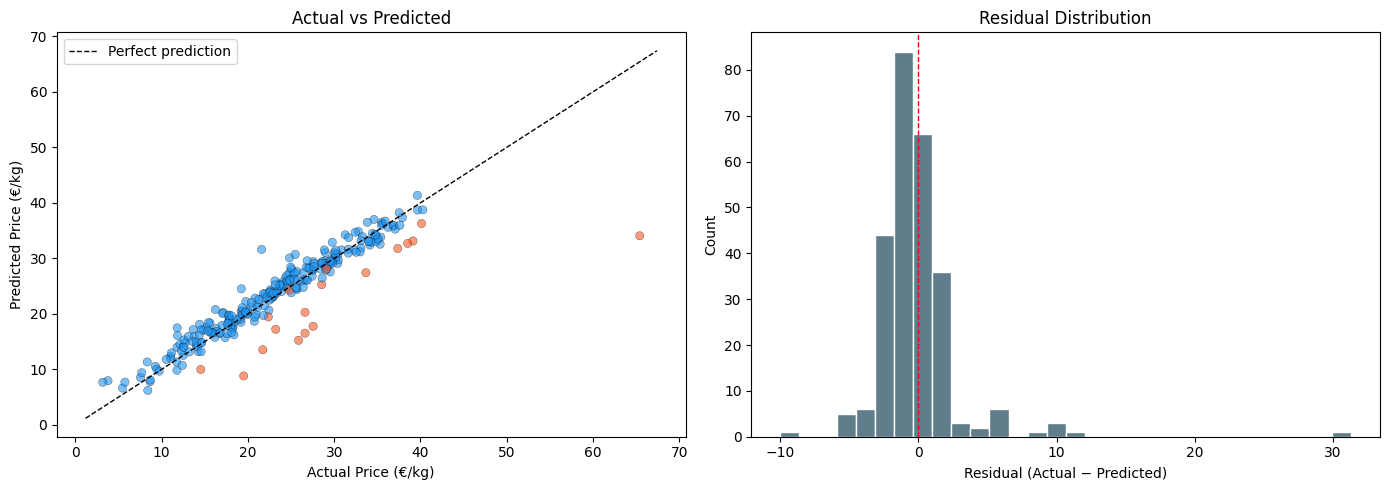

Mean residual: -0.1515  (should be near 0)
Std residual:  3.1279


In [9]:
# ============================================================
# Step 9: Residual Plot — Actual vs Predicted
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Actual vs Predicted scatter ---
colors = ['#2196F3' if s == 0 else '#FF5722' for s in is_stress_test]
axes[0].scatter(y_test, y_pred, c=colors, alpha=0.6, edgecolors='k', linewidths=0.3)
lo = min(y_test.min(), y_pred.min()) - 2
hi = max(y_test.max(), y_pred.max()) + 2
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (€/kg)')
axes[0].set_ylabel('Predicted Price (€/kg)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# --- Right: Residual distribution ---
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=30, color='#607D8B', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f}  (should be near 0)')
print(f'Std residual:  {residuals.std():.4f}')

## Step 10 — Feature Importance

Which features drive predictions now that the model has seen both distributions?

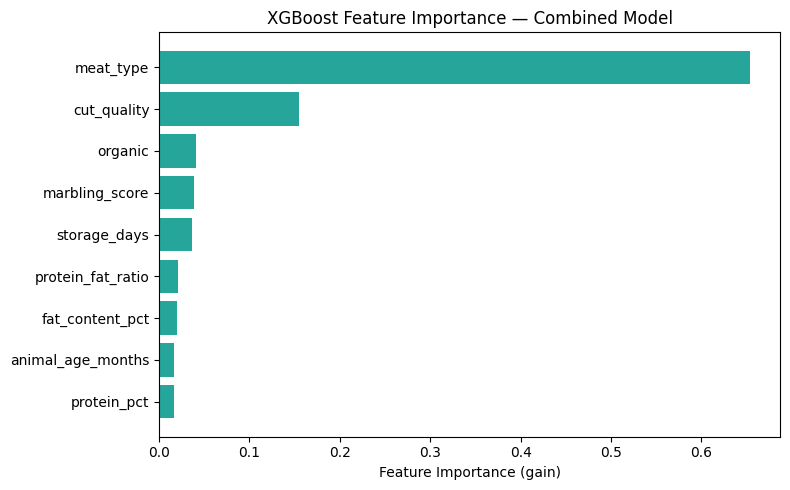

In [10]:
# ============================================================
# Step 10: Feature Importance
# ============================================================

importances = model.feature_importances_
feat_names  = X_train.columns
sorted_idx  = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(feat_names[sorted_idx], importances[sorted_idx], color='#26A69A')
plt.xlabel('Feature Importance (gain)')
plt.title('XGBoost Feature Importance — Combined Model')
plt.tight_layout()
plt.show()

## Summary & Next Steps

| Step | What we did |
|------|------------|
| NB1 | Trained on clean data → strong R² on clean test, collapsed on stress test |
| NB2 | Added group imputation + clipping → marginal stress improvement, R² still negative |
| **NB3** | **Combined train/test → model sees both distributions, R² should be positive** |

**Possible next steps:**
- Hyperparameter tuning via `GridSearchCV` or `RandomizedSearchCV`
- Cross-validation (5-fold) for more stable metrics
- Try `LightGBM` or `CatBoost` as alternative gradient boosters
- Add more engineered features (interactions, polynomial terms)
- SHAP values for model explainability